In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("salmas-workspace-kfhpp").project("luxor-temple-scenes-recognition")
version = project.version(4)
dataset = version.download("yolov11")


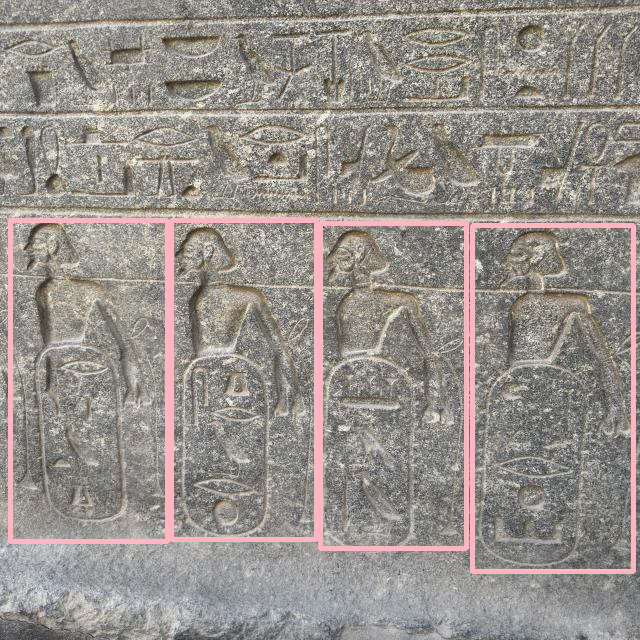

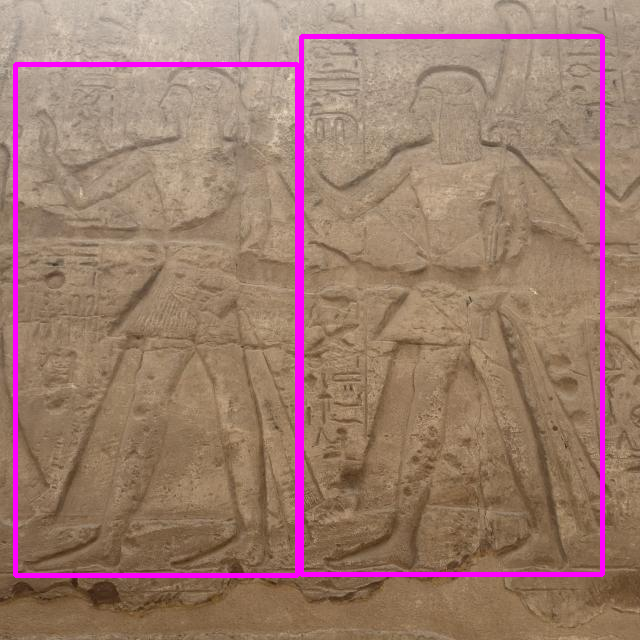

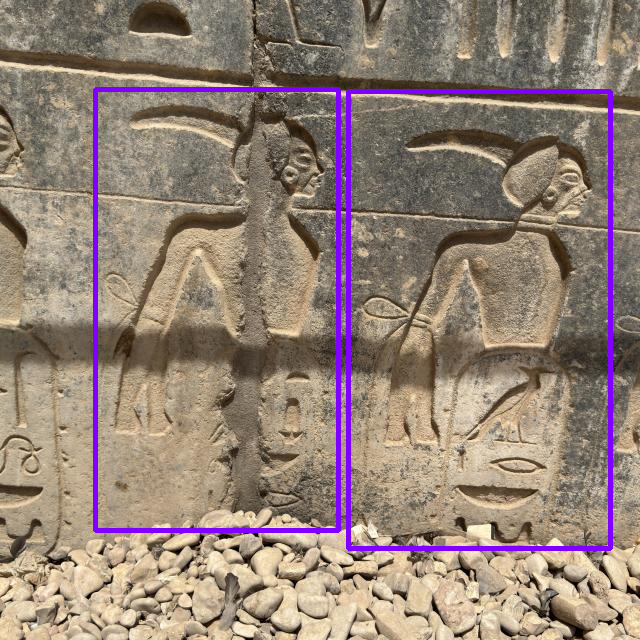

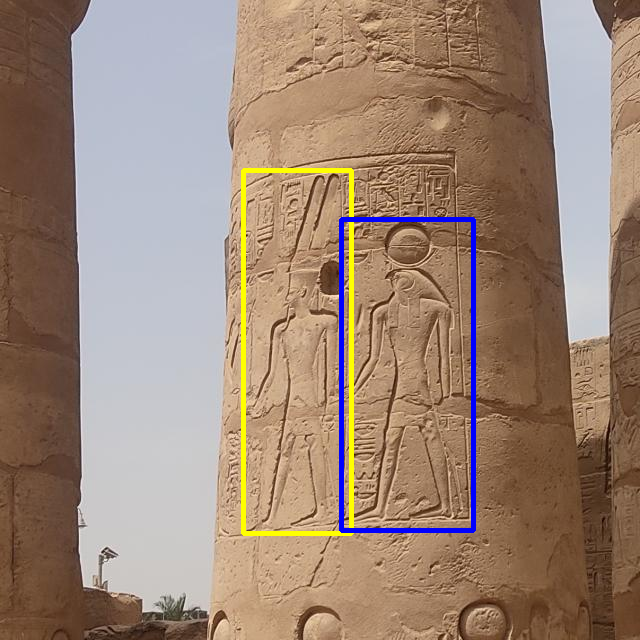

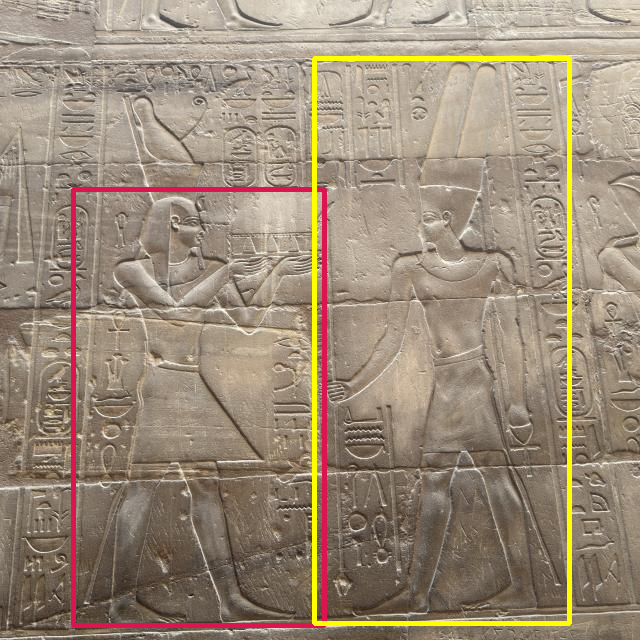

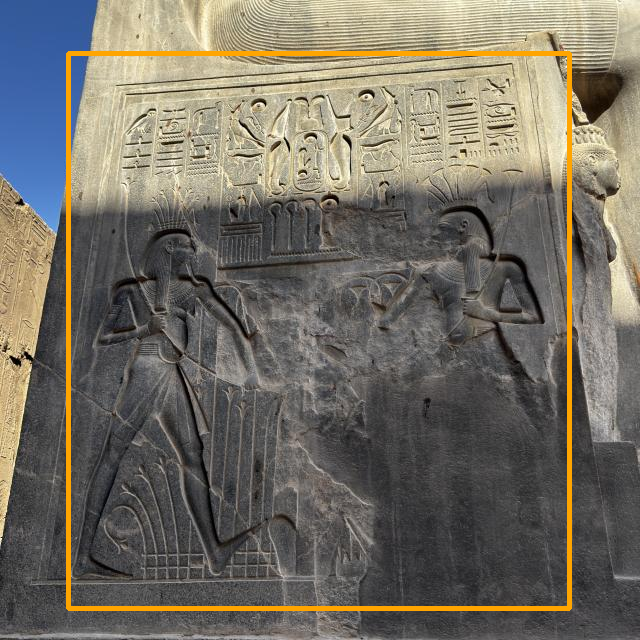

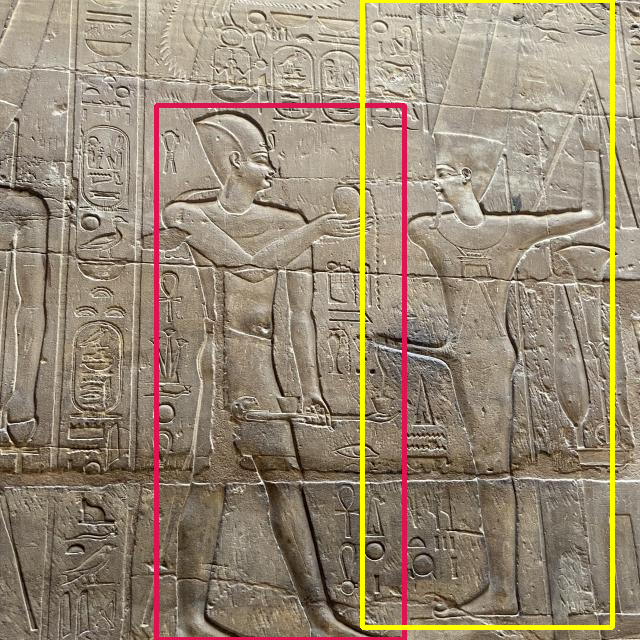

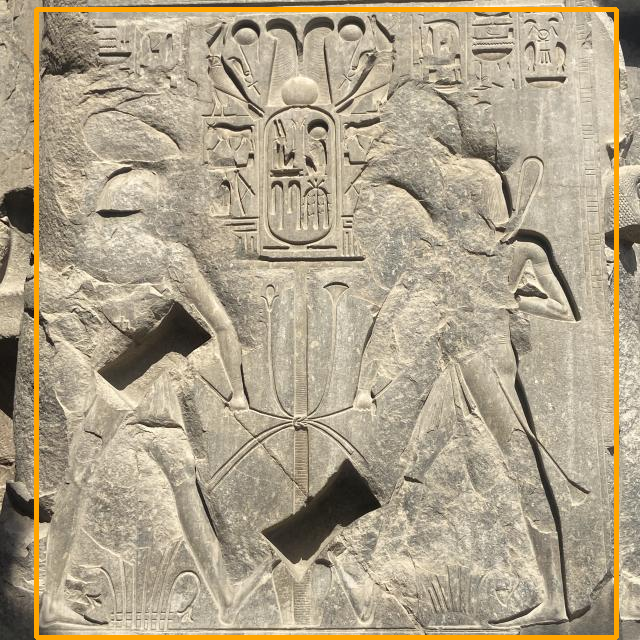

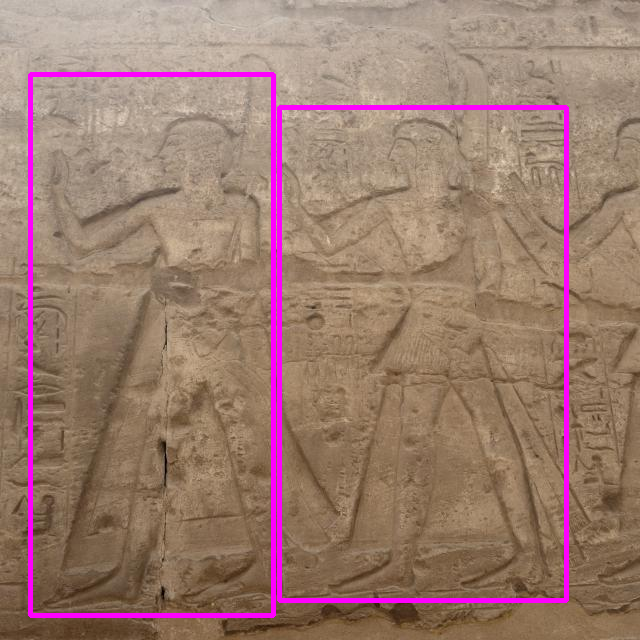

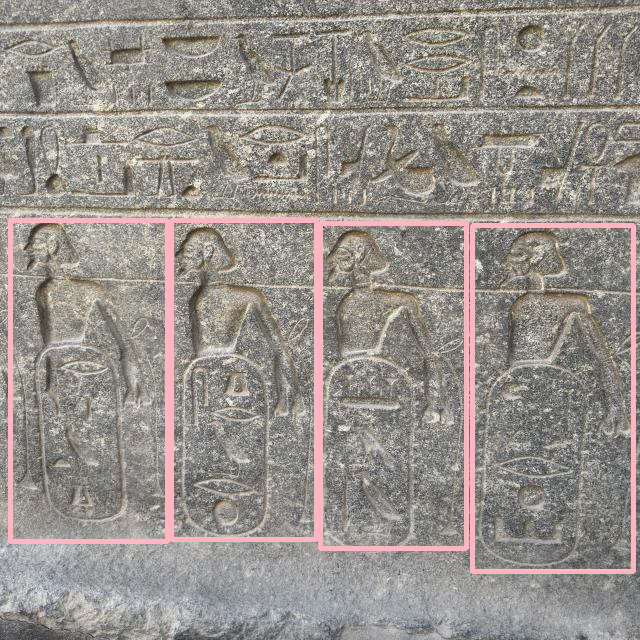

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import os
import random
import numpy as np


images_folder = '/content/Luxor-temple-scenes-recognition-4/valid/images'
labels_folder = '/content/Luxor-temple-scenes-recognition-4/valid/labels/'

classes = {
    0: {"color": (193, 182, 255), "label": "africans"},       # Light Pink
    1: {"color": (255, 0, 128), "label": "alexander"},        # Purple
    2: {"color": (80, 20, 220), "label": "amun"},             # Crimson/Red-Pink
    3: {"color": (0, 255, 255), "label": "Asiatics"},         # Yellow
    4: {"color": (255, 0, 0), "label": "horus"},              # Blue
    5: {"color": (255, 255, 0), "label": "monkeys"},          # Cyan/Light Blue
    6: {"color": (193, 182, 255), "label": "mut"},            # Light Pink
    7: {"color": (80, 20, 220), "label": "ramses"},           # Crimson/Red-Pink
    8: {"color": (255, 0, 255), "label": "son of ramses"},    # Magenta
    9: {"color": (0, 165, 255), "label": "uniting scene"},    # Orange
    10: {"color": (42, 42, 165), "label": "werethekau"}       # Brown
}

thickness = 3

images = os.listdir(images_folder)

for i in range(10):
  image = images[random.randint(0, len(images) - 1)]
  filename = image[0:-4] + '.txt'
  image = cv2.imread(f'{images_folder}/{image}')
  x, y, _ = image.shape
  with open(f'{labels_folder}/{filename}', 'r') as file:
    for line in file:
      cls, center_x, center_y, width, height = line.split()
      center_x, center_y, width, height = float(center_x) * x, float(center_y) * y, float(width) * x, float(height) * y
      pt1 = (int(center_x - width/2), int(center_y - height/2))
      pt2 = (int(center_x + width/2), int(center_y + height/2))
      cv2.rectangle(image, pt1, pt2, classes[int(cls)]['color'], thickness)
    cv2_imshow(image)


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

model.train(data="/content/Luxor-temple-scenes-recognition-4/data.yaml",
            epochs=300,
            imgsz=640,
            patience=50,
            mosaic=0.5,
            close_mosaic=15,
            plots=True,
            dropout=0.1
            )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Luxor-temple-scenes-recognition-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d7ba784c50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [ ]:
import shutil
import os

drive_folder = '/content/drive/MyDrive/Luxor_Temple_Models'
os.makedirs(drive_folder, exist_ok=True)

source_path = '/content/runs'

destination_path = f'{drive_folder}/runs'
shutil.copytree(source_path, destination_path)

print(f"Success! Your runs are safely backed up to: {destination_path}")

Success! Your runs are safely backed up to: /content/drive/MyDrive/Luxor_Temple_Models/runs3


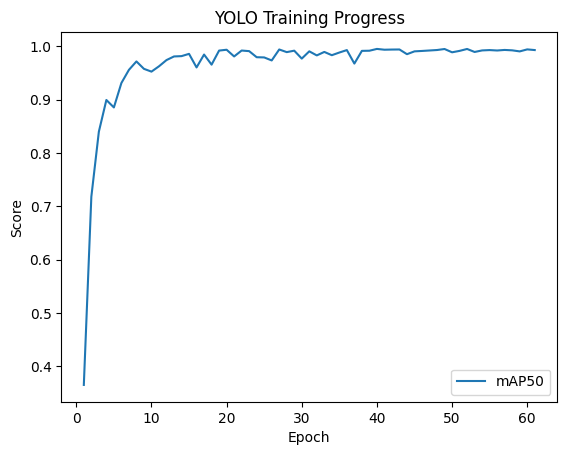

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('runs/detect/train/results.csv')
df.columns = df.columns.str.strip()

plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('YOLO Training Progress')
plt.legend()
plt.show()


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

# Export to TFLite with INT8 quantization for maximum mobile speed
model.export(format="tflite", int8=True)

In [ ]:
# model = YOLO("/content/runs/detect/train/weights/best.pt")
metrics = model.val(data=f"/content/drive/MyDrive/Luxor_Temple_Models/data/data.yaml", split='test')

print(f"Final mAP@50:95: {metrics.box.map:.3f}")
print(f"Final mAP@50: {metrics.box.map50:.3f}")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,469,437 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.8 ms, read: 0.3±0.0 MB/s, size: 106.8 KB)
val: Scanning /content/drive/MyDrive/Luxor_Temple_Models/data/test/labels.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 11.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 7.0s/it 28.0s
                   all         51        121      0.931      0.971      0.979      0.772
              Asiatics          4         17      0.962          1      0.995      0.817
              africans          3         12      0.956          1      0.995      0.857
             alexander         14         14      0.958          1      0.995      0.827
                  amun         27         27      0.911          1      0.954      0.787
                 horus 